In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/sample_submission.csv
/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/train.csv
/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/test.csv


# Import Libraries

Importing all necessary libraries

In [2]:
import pandas as pd
import numpy as np
import warnings
import time
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.metrics import (classification_report,confusion_matrix, ConfusionMatrixDisplay)
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score

# Data Loading

Loading the Training and Test Datasets

In [3]:
train_df = pd.read_csv('/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/train.csv')
test_df  = pd.read_csv('/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/test.csv')

In [4]:
print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)
train_df.head()

Train shape: (7000, 26)
Test shape:  (1124, 25)


,ID,mushroom_id,cap-shape,cap-surface,cap-color,bruises,number_of_bruises,odor,gill-attachment,gill-spacing,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,1,0,convex,smooth,brown,bruises,7,pungent,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,scattered,urban,p
1,2,1,convex,smooth,yellow,bruises,20,almond,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,brown,numerous,grasses,e
2,3,3,convex,scaly,white,bruises,11,pungent,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,scattered,urban,p
3,4,4,convex,smooth,gray,no,0,NaN,gills free from stalk,crowded,...,white,white,partial,white,1.0,evanescent,brown,abundant,grasses,e
4,5,5,convex,scaly,yellow,bruises,8,almond,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,numerous,grasses,e


The training dataset has **7000 rows, 26 columns**

The test dataset has **1124 rows, 25 columns**

# Data Types 
**Rubric task 1:** Identify data types of different columns

In [5]:
print("=== DATA TYPES ===")
print(train_df.info())
print("\n=== COLUMN CATEGORIES ===")
print("Numerical columns: ", train_df.select_dtypes(include=['int64','float64']).columns.tolist())
print("Categorical columns: ", train_df.select_dtypes(include=['object']).columns.tolist())

=== DATA TYPES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        7000 non-null   int64  
 1   mushroom_id               7000 non-null   int64  
 2   cap-shape                 7000 non-null   object 
 3   cap-surface               7000 non-null   object 
 4   cap-color                 7000 non-null   object 
 5   bruises                   7000 non-null   object 
 6   number_of_bruises         7000 non-null   int64  
 7   odor                      3764 non-null   object 
 8   gill-attachment           7000 non-null   object 
 9   gill-spacing              7000 non-null   object 
 10  gill-size                 7000 non-null   object 
 11  gill-color                7000 non-null   object 
 12  stalk-shape               7000 non-null   object 
 13  stalk-root                6808 non-null   ob

There are **4 Numerical** (3 integer and 1 float) features and **23 Categorical** features in our dataset along with **1 target variable: `class`**.

# Descriptive Statistics
**Rubric Task 2:** Present descriptive statistics of numerical columns

In [6]:
desc = train_df.describe().T
desc['median'] = train_df.median(numeric_only=True)
desc

,count,mean,std,min,25%,50%,75%,max,median
ID,7000.0,3500.500000,2020.870275,1.0,1750.75,3500.5,5250.25,7000.0,3500.5
mushroom_id,7000.0,3850.617714,2208.389867,0.0,2000.75,3755.5,5602.25,8118.0,3755.5
number_of_bruises,7000.0,5.459571,7.723528,0.0,0.00,0.0,11.00,24.0,0.0
ring-number,6964.0,1.080988,0.272836,1.0,1.00,1.0,1.00,2.0,1.0


### Summary Analysis

- **Dataset Size:**  
  Most columns (`ID`, `mushroom_id`, `number_of_bruises`) have 7000 observations, while `ring-number` has slightly fewer (6964), indicating some missing values in that column.

- **ID Columns:**  
  `ID` and `mushroom_id` are evenly distributed identifiers with large ranges. Their means and medians are centered, suggesting uniform indexing rather than meaningful numerical features.

- **Number of Bruises:**  
  Highly skewed distribution. Median = 0 and 25th percentile = 0, meaning most mushrooms have no bruises. However, the maximum (24) and relatively high standard deviation indicate a few mushrooms with many bruises.

- **Ring Number:**  
  Very low variability. Mean ≈ 1.08 and median = 1, with most values being 1 and a few 2s. This suggests it is a near-constant feature with limited predictive power.

- **Spread & Variability:**  
  `number_of_bruises` shows the highest variability (std ≈ 7.72), while `ring-number` has very low variability (std ≈ 0.27).

- **Outliers:**  
  The `number_of_bruises` feature contains extreme values compared to its median, indicating potential outliers or rare cases.

#  Identify Missing Values
**Rubric Task 3:** Identify and handle the missing values

In [7]:
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df)) * 100
pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct}).query('`Missing Count` > 0')

,Missing Count,Percentage
odor,3236,46.228571
stalk-root,192,2.742857
ring-number,36,0.514286
ring-type,36,0.514286


We can see there are **4 columns that contain missing values** (1 numerical and 3 categorical).

We will impute the missing values as:
- `odor`: fill with 'unknown' to preserve the column as odor can be a predictor
- `stalk-root` and `ring-type`: fill with mode as categorical
- `ring-number`: fill with median as numerical

For test dataset, we use train stats


In [8]:
train_df['odor'] = train_df['odor'].fillna('unknown')
test_df['odor']  = test_df['odor'].fillna('unknown')


stalk_mode = train_df['stalk-root'].mode()[0]
train_df['stalk-root'] = train_df['stalk-root'].fillna(stalk_mode)
test_df['stalk-root']  = test_df['stalk-root'].fillna(stalk_mode)

ringtype_mode = train_df['ring-type'].mode()[0]
train_df['ring-type'] = train_df['ring-type'].fillna(ringtype_mode)
test_df['ring-type']  = test_df['ring-type'].fillna(ringtype_mode)


ring_median = train_df['ring-number'].median()
train_df['ring-number'] = train_df['ring-number'].fillna(ring_median)
test_df['ring-number']  = test_df['ring-number'].fillna(ring_median)



print("Missing values in train after handling:", train_df.isnull().sum().sum())
print("Missing values in Test after handling:", test_df.isnull().sum().sum())

Missing values in train after handling: 0
Missing values in Test after handling: 0


#  Identify & Remove Duplicates
**Rubric Task 4:** Identify and handle duplicates

In [9]:
print("Duplicate rows found:", train_df.duplicated().sum())
train_df.drop_duplicates(inplace=True)
print("Shape after removing duplicates:", train_df.shape)

Duplicate rows found: 0
Shape after removing duplicates: (7000, 26)


It is evident that there are **no duplicate rows** in the dataset.

# Outlier Detection & Handling
**Rubric Task 5:** Identify and handle outliers

We use the **IQR (Interquartile Range) method** to detect outliers:
- Q1 = 25th percentile, Q3 = 75th percentile
- IQR = Q3 - Q1


number_of_bruises:
  Q1=0.0, Q3=11.0, IQR=11.0
  Lower bound=-16.5, Upper bound=27.5
  Number of outliers: 0

ring-number:
  Q1=1.0, Q3=1.0, IQR=0.0
  Lower bound=1.0, Upper bound=1.0
  Number of outliers: 564


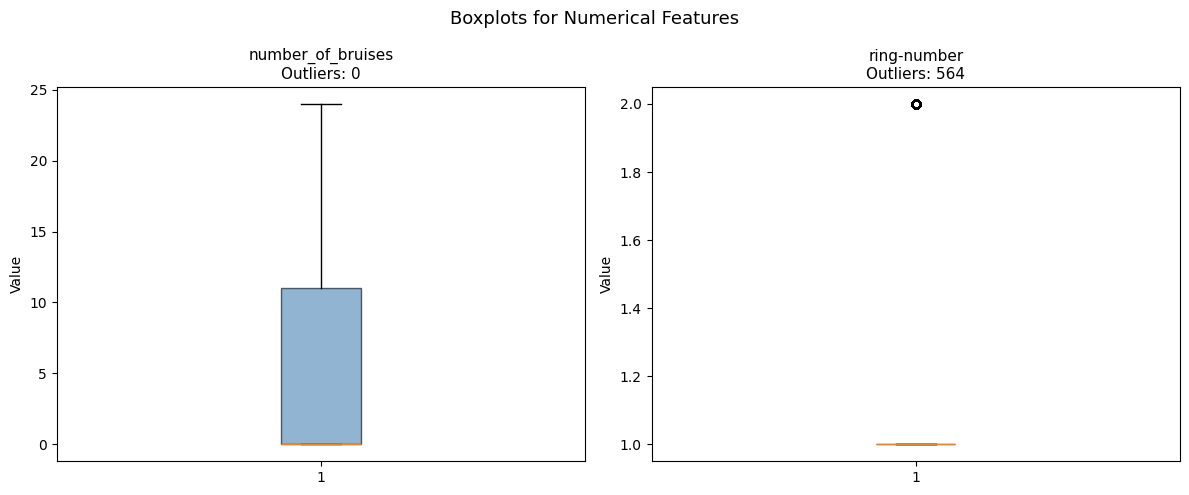

In [10]:
outlier_cols = ['number_of_bruises', 'ring-number']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, col in enumerate(outlier_cols):
    Q1  = train_df[col].quantile(0.25)
    Q3  = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((train_df[col] < lower) | (train_df[col] > upper)).sum()
    
    axes[i].boxplot(train_df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(f'{col}\nOutliers: {n_outliers}', fontsize=11)
    axes[i].set_ylabel('Value')
    
    print(f"\n{col}:")
    print(f"  Q1={Q1}, Q3={Q3}, IQR={IQR}")
    print(f"  Lower bound={lower}, Upper bound={upper}")
    print(f"  Number of outliers: {n_outliers}")

plt.suptitle('Boxplots for Numerical Features', fontsize=13)
plt.tight_layout()
plt.show()

### Analysis

Outlier detection was performed using the **IQR method** on all numerical columns.

- **ID:**
  Uniformly distributed row identifier ranging from 1 to 7000.
  Not a feature thus excluded from outlier analysis as it carries no predictive value.

- **mushroom_id:**
  An arbitrary identifier for each mushroom sample with no biological meaning.
  Not a feature thus excluded from outlier analysis for the same reason as `ID`.

- **number_of_bruises:**
  IQR method found **0 outliers** (lower bound = -16.5, upper bound = 27.5).
  The maximum value of 24 falls well within the acceptable range.
  No action taken.

- **ring-number:**
  IQR = 0.0 because over 75% of values are exactly 1.0, causing the method to flag
  the value 2 as an outlier (564 instances). This is a **false positive** — having 2 rings
  is a valid biological trait of certain mushroom species, not a data error.
  These rows are **retained**. `ring-number` behaves as a low-variance near-constant
  feature and will be treated accordingly during encoding.

**Overall:** No rows were dropped as a result of outlier analysis. All flagged values
represent legitimate biological observations rather than data entry errors or measurement anomalies.

# Correlation Analysis

We will now perform a correlation analysis to understand the relationships between numerical features and the target variable **class**.

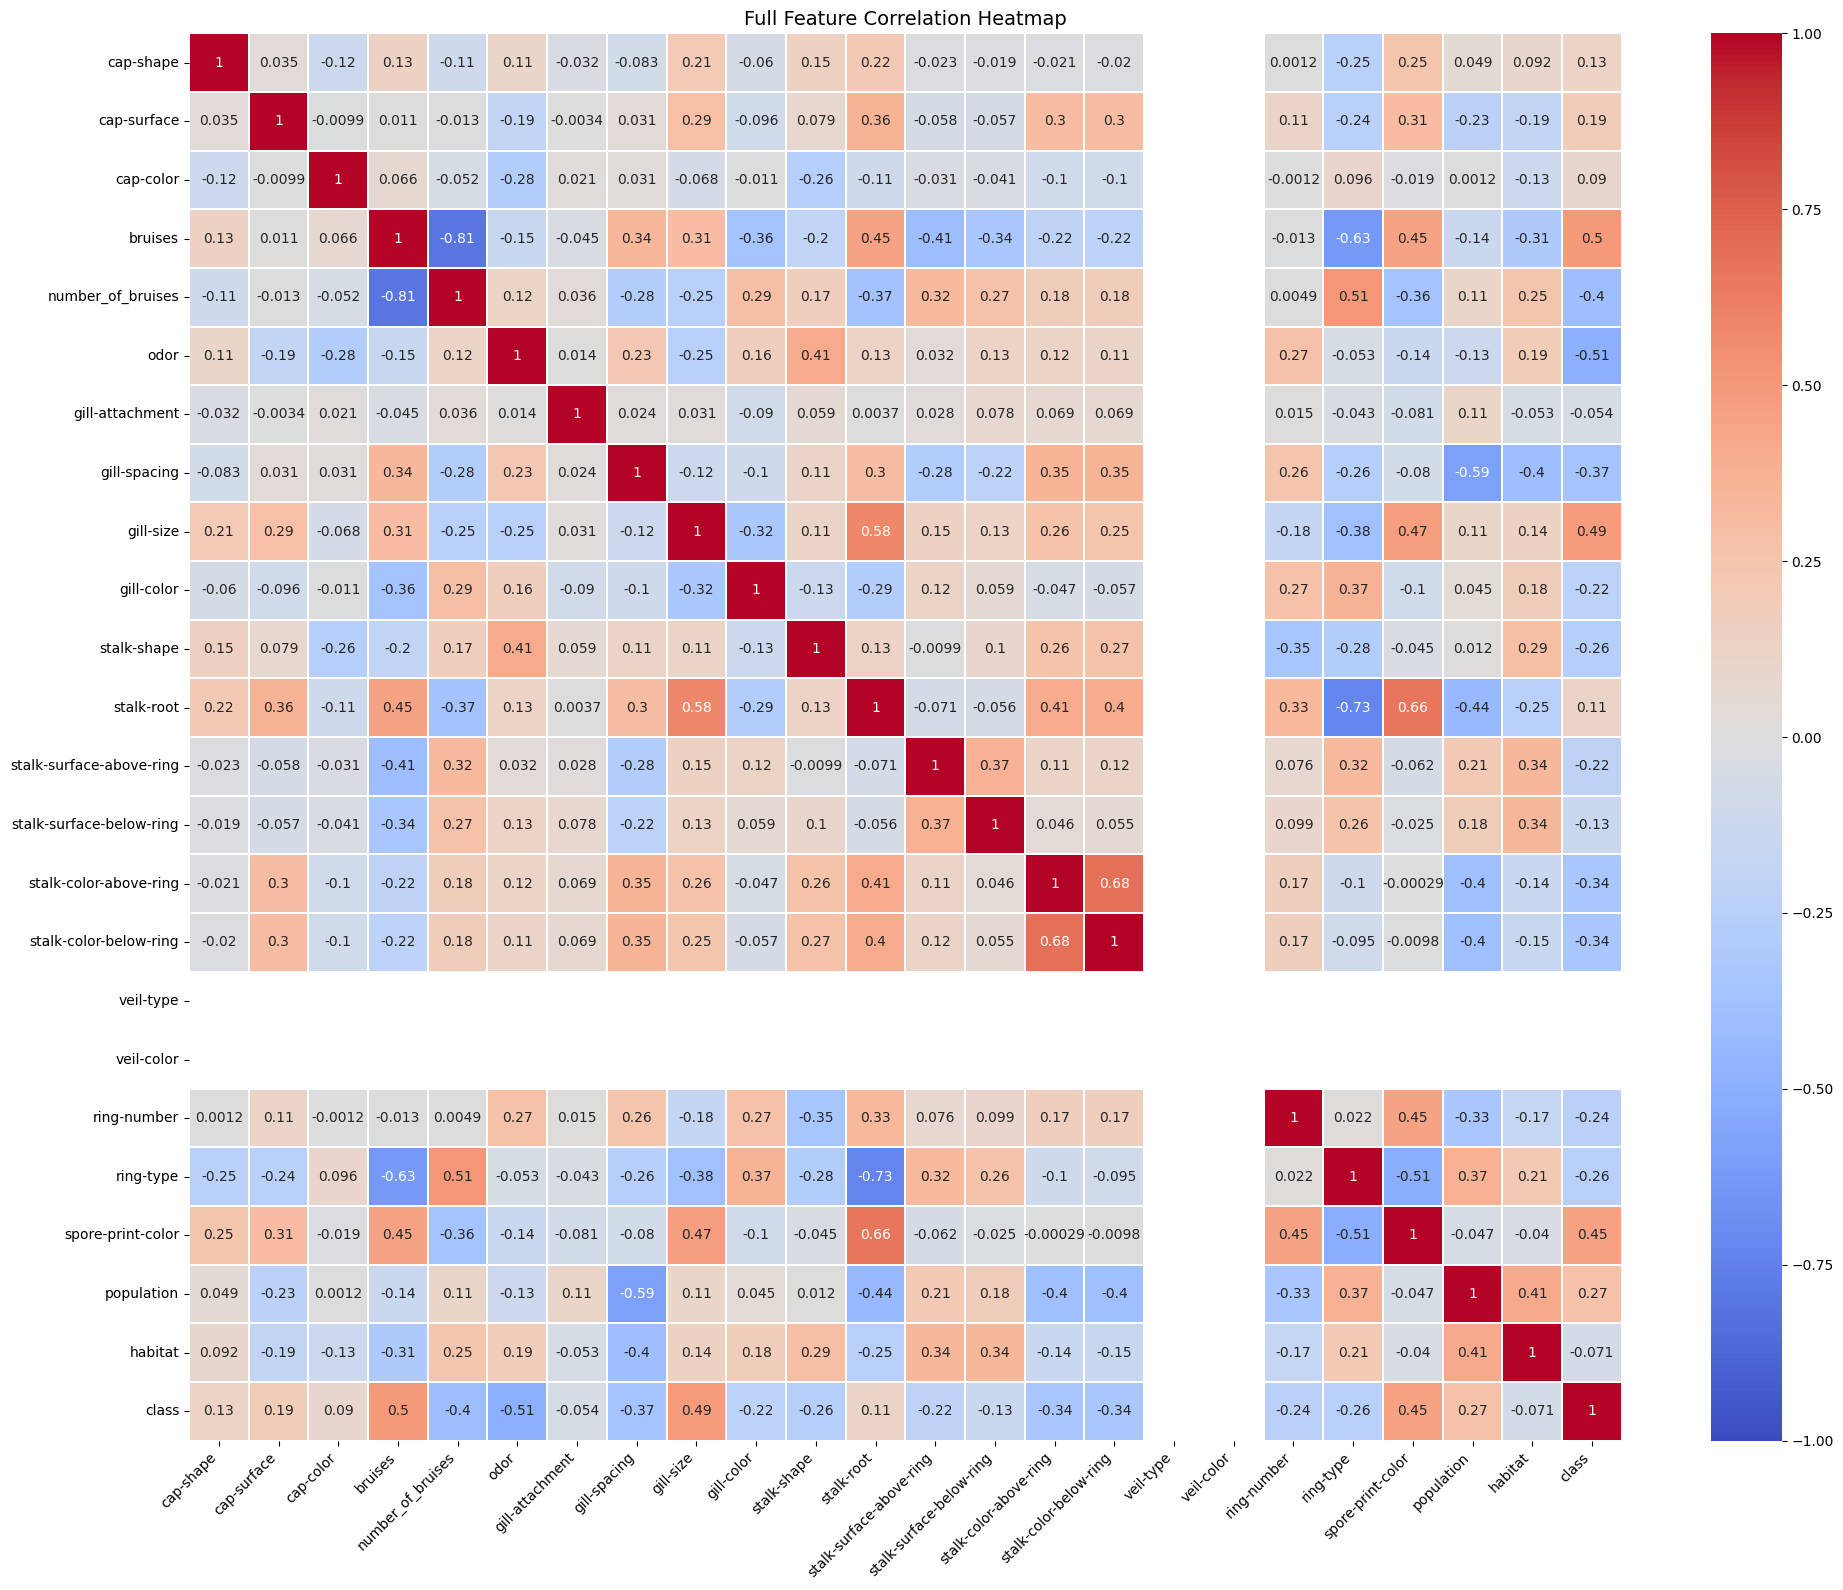

In [11]:
df_corr = train_df.copy()
df_corr = df_corr.drop(columns=['ID', 'mushroom_id'])

le = LabelEncoder()
for col in df_corr.columns:
    df_corr[col] = le.fit_transform(df_corr[col].astype(str))

corr_matrix = df_corr.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',
            linewidths=0.3, vmin=-1, vmax=1)
plt.title('Full Feature Correlation Heatmap', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
print("\nAll feature correlations with class (sorted):")
print(corr_matrix['class'].sort_values(ascending=False).round(4).to_string())


All feature correlations with class (sorted):
class                       1.0000
bruises                     0.4988
gill-size                   0.4868
spore-print-color           0.4537
population                  0.2669
cap-surface                 0.1912
cap-shape                   0.1262
stalk-root                  0.1099
cap-color                   0.0903
gill-attachment            -0.0539
habitat                    -0.0711
stalk-surface-below-ring   -0.1343
stalk-surface-above-ring   -0.2160
gill-color                 -0.2236
ring-number                -0.2407
ring-type                  -0.2560
stalk-shape                -0.2629
stalk-color-above-ring     -0.3374
stalk-color-below-ring     -0.3414
gill-spacing               -0.3666
number_of_bruises          -0.4012
odor                       -0.5059
veil-type                      NaN
veil-color                     NaN


### Analysis

- **Strong Positive Correlations:**  
  - `bruises` (0.4988), `gill-size` (0.4868), and `spore-print-color` (0.4537) show the highest positive relationships with the target.  
  - These features are likely strong indicators for classification and may significantly influence model predictions.

- **Moderate Positive Correlations:**  
  - `population` (0.2669), `cap-surface` (0.1912), and `cap-shape` (0.1262) show weaker but still meaningful positive relationships.  
  - These may contribute to model performance when combined with stronger features.

- **Weak Positive Correlations:**  
  - `stalk-root` (0.1099) and `cap-color` (0.0903) have minimal influence individually.

- **Weak Negative Correlations:**  
  - Features like `gill-attachment` (-0.0539) and `habitat` (-0.0711) have very small negative relationships, suggesting limited predictive value on their own.

- **Moderate Negative Correlations:**  
  - `stalk-surface-below-ring` (-0.1343), `stalk-surface-above-ring` (-0.2160), `gill-color` (-0.2236), `ring-number` (-0.2407), and `ring-type` (-0.2560) show moderate inverse relationships with the target.

- **Strong Negative Correlations:**  
  - `stalk-shape` (-0.2629), `stalk-color-above-ring` (-0.3374), `stalk-color-below-ring` (-0.3414), and `gill-spacing` (-0.3666) have stronger negative influence.  
  - `number_of_bruises` (-0.4012) and especially `odor` (-0.5059) are the most negatively correlated features, indicating high importance for classification.

- **Near-Zero / Low Impact Features:**  
  - Features with correlations close to zero contribute little individually and may not significantly impact the model unless interacting with others.

- **Missing / Constant Features:**  
  - `veil-type` and `veil-color` have `NaN` correlations, likely due to being constant (no variance). These features should be removed as they provide no useful information.

- **Modeling Insight:**  
  - Both positively and negatively correlated features are important.  
  - High absolute correlation features (`odor`, `bruises`, `gill-size`) should be prioritized.  
  - We will remove low-variance or non-informative features to improve model efficiency.

# Selecting Features

Dropping features that do not contribute to the model

In [13]:
# Dropping ID and non-informative columns

cols_to_drop = ['ID', 'mushroom_id', 'veil-type', 'veil-color']

train_df = train_df.drop(columns=cols_to_drop)

print("Dropped columns:", cols_to_drop)
print("Remaining columns:", train_df.shape[1])

Dropped columns: ['ID', 'mushroom_id', 'veil-type', 'veil-color']
Remaining columns: 22


# Visualizations
**Rubric Task 6:** Present at least three visualizations and provide insights for the same

#### Viz 1:
Based on the correlation analysis, we selected the top three features (`odor`, `bruises`, and `gill-size`) to visualize against our target variable to understand their predictive power.

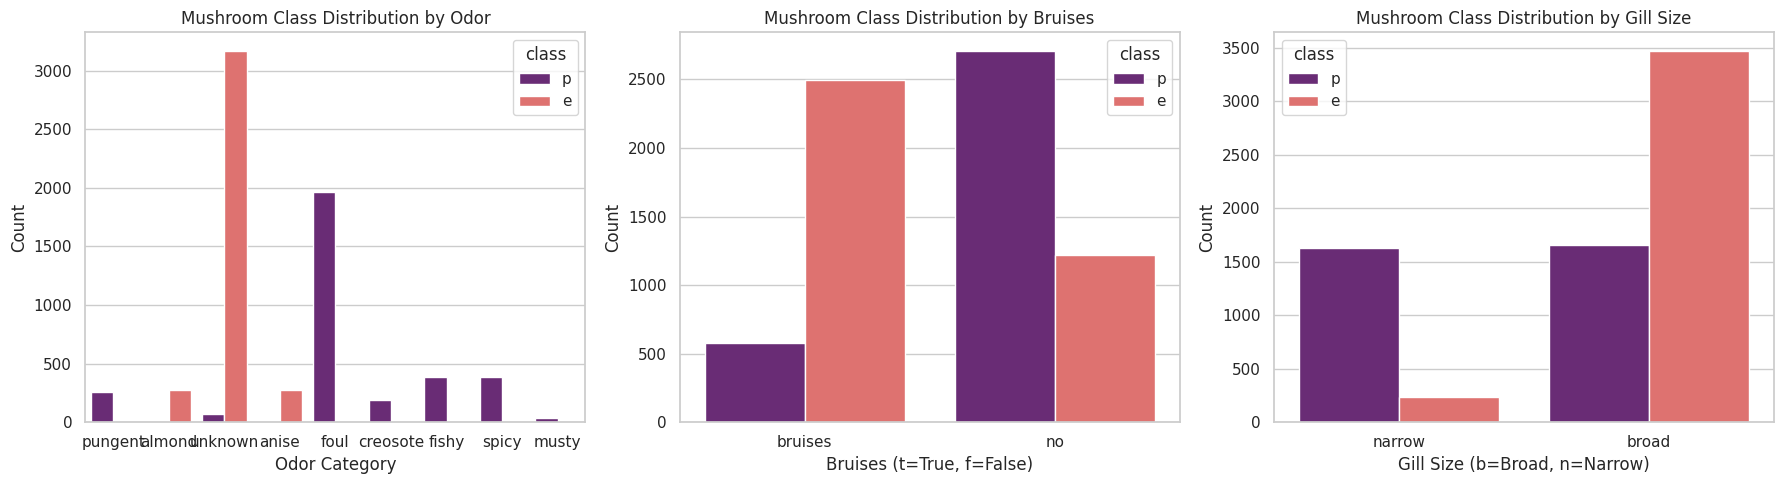

In [14]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=train_df, x='odor', hue='class', ax=axes[0], palette='magma')
axes[0].set_title('Mushroom Class Distribution by Odor')
axes[0].set_xlabel('Odor Category')
axes[0].set_ylabel('Count')

sns.countplot(data=train_df, x='bruises', hue='class', ax=axes[1], palette='magma')
axes[1].set_title('Mushroom Class Distribution by Bruises')
axes[1].set_xlabel('Bruises (t=True, f=False)')
axes[1].set_ylabel('Count')

sns.countplot(data=train_df, x='gill-size', hue='class', ax=axes[2], palette='magma')
axes[2].set_title('Mushroom Class Distribution by Gill Size')
axes[2].set_xlabel('Gill Size (b=Broad, n=Narrow)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Insights:** The visualizations show that odor is the strongest distinguishing feature, with certain odor categories (like foul and pungent) almost exclusively associated with poisonous mushrooms, while others align with edible ones. 
Bruises also provide useful separation, as mushrooms with bruises tend to be edible, whereas those without are more likely poisonous. Similarly, gill size shows a clear pattern, where broad gills are more common in poisonous mushrooms and narrow gills in edible ones. Overall, these features exhibit strong class separation and are likely to be highly influential in model predictions.

#### Viz 2:

Next, we look at where these mushrooms grow. By plotting the counts of poisonous and edible mushrooms across different habitats, we can identify environmental risk factors (e.g., whether mushrooms found on paths are more dangerous than those in the woods).

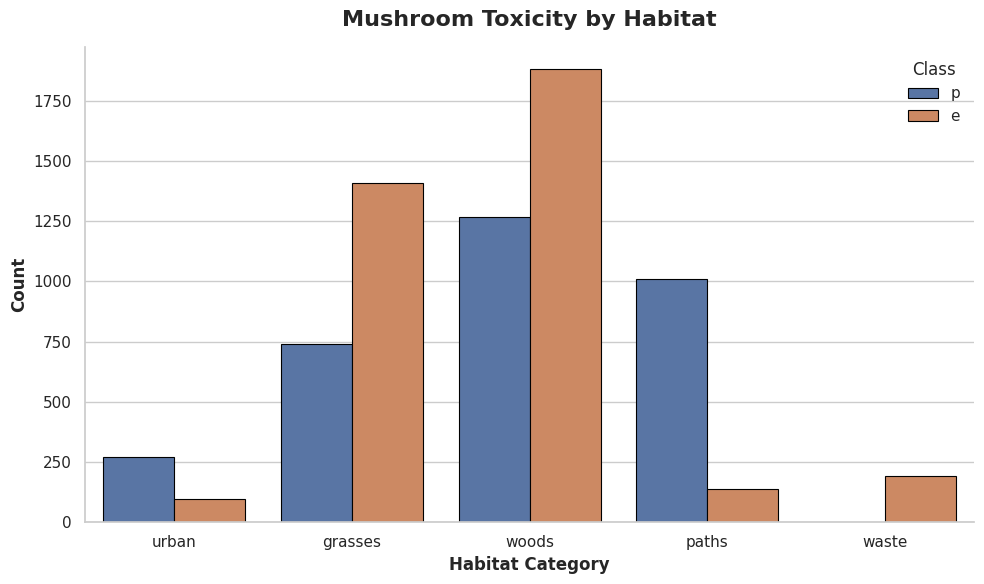

In [15]:
plt.figure(figsize=(10, 6))

sns.countplot(data=train_df, x='habitat', hue='class', edgecolor='black', linewidth=0.8)

plt.title('Mushroom Toxicity by Habitat', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Habitat Category', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')

sns.despine() 

plt.legend(title='Class', frameon=False, loc='upper right')
plt.tight_layout()
plt.show()

**Insights:** The habitat feature shows some variation in mushroom toxicity. While certain habitats like woods and grasses have a higher count of edible mushrooms, others such as paths and urban areas show a relatively higher proportion of poisonous ones. However, since both edible and poisonous mushrooms are present across most habitats, this feature alone is not a strong predictor and provides limited discriminatory power for classification.

#### Viz 3: 
We also measure the metric of **co-occurrence**. By cross-tabulating `odor` with `spore-print-color`, we can visualize which combinations of physical traits appear most frequently together. This helps us spot deep structural patterns in the data before we even train a model.

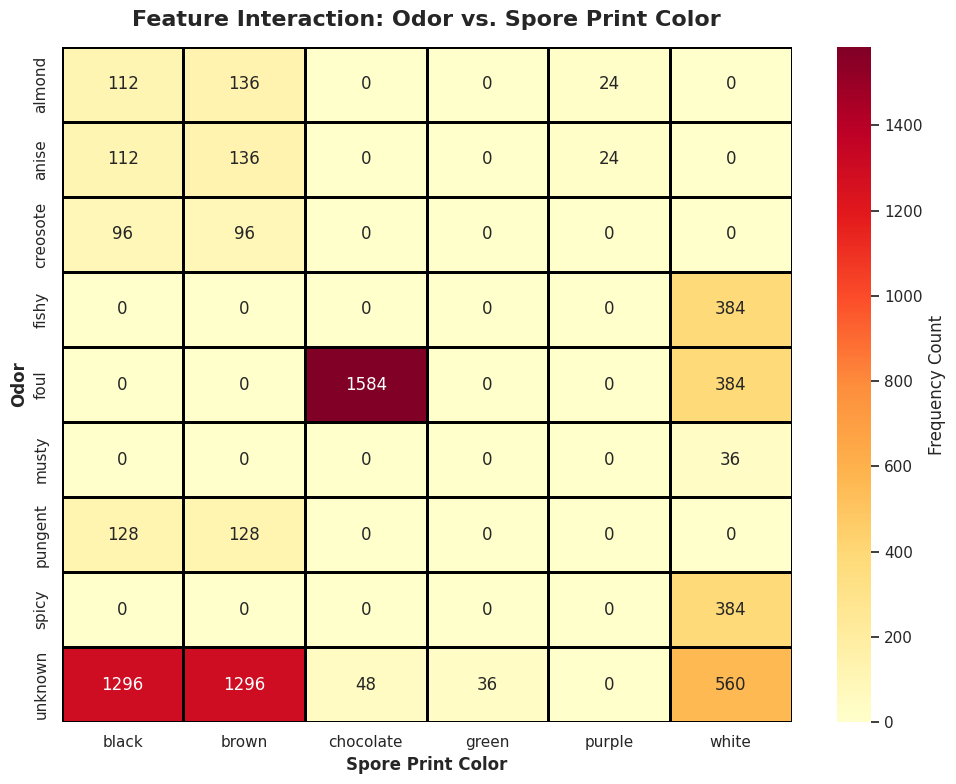

In [16]:
plt.figure(figsize=(10, 8))

# Calculate the co-occurrence metric between two highly predictive features
interaction_matrix = pd.crosstab(train_df['odor'], train_df['spore-print-color'])

# Plot as an annotated heatmap
sns.heatmap(interaction_matrix, cmap='YlOrRd', annot=True, fmt='d', 
            linewidths=1, linecolor='black', cbar_kws={'label': 'Frequency Count'})

plt.title('Feature Interaction: Odor vs. Spore Print Color', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Spore Print Color', fontsize=12, fontweight='bold')
plt.ylabel('Odor', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

**Insights:** The interaction between odor and spore print color reveals strong patterns that are not visible when considering each feature individually. Certain combinations, such as foul odor with chocolate spore print color, occur very frequently and likely correspond to a specific class, indicating high predictive power.
Similarly, some odor categories map almost exclusively to specific spore colors (e.g., fishy, spicy → white), showing clear clustering.

# Scaling and Encoding
**Rubric Task 7:** Scale Numerical features and Encode Categorical features

### Encoding Strategy

Machine learning models require numerical input, but our entire dataset consists of text-based categorical values (e.g., 'p', 'e', 'x', 'f'). 
* **Target Variable (`class`):** We will use `LabelEncoder` to convert our target into a binary format (0 for Edible, 1 for Poisonous).
* **Predictor Variables:** We will use One-Hot Encoding for our features. This creates a new binary column for each category. We use `drop_first=True` to avoid the "dummy variable trap", which can break certain models.

In [17]:
# 1. Separate features (X) and target (y) from the training data
X_raw = train_df.drop('class', axis=1)
y_raw = train_df['class']

X_test_raw = test_df.copy() 

# 2. Label Encode 'class' varaible
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)

# 3. OHE Predictor Variables
X_encoded = pd.get_dummies(X_raw, drop_first=True, dtype=int)
X_test_encoded = pd.get_dummies(X_test_raw, drop_first=True, dtype=int)

# 4. Align columns to ensure the test set has the exact same dummy columns
X_encoded, X_test_encoded = X_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

print(f"Shape of full encoded features: {X_encoded.shape}")
print(f"Shape of Kaggle test features: {X_test_encoded.shape}")

Shape of full encoded features: (7000, 79)
Shape of Kaggle test features: (1124, 79)


### Scaling Strategy

Standard scaling  is crucial when dataset features have vastly different ranges (e.g., Age 0-100 vs. Salary $0-$100,000). 
* Since our dataset is almost 100% categorical, One-Hot Encoding transforms all our features into binary values (0 and 1). Because all features are now on the exact same 0-1 scale, applying a numerical scaler is entirely unnecessary, adds no predictive value, and would actually destroy the interpretability of our binary columns.

### Creating Train-Validation Split

Before scaling, we split our data into a **training set** and a **validation set**.

- **Training set (80%)** — the model learns patterns from this data
- **Validation set (20%)** — held back completely to evaluate how well the model generalizes to unseen data

We use `random_state=4524` to ensure the split is reproducible — every time the notebook is run, the same rows are assigned to train and validation.

In [18]:
X_train, X_val, y_train, y_val = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=4524)

print(f"Shape of X_train (for training models): {X_train.shape}")
print(f"Shape of X_val (for evaluating models): {X_val.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_val: {y_val.shape}")

Shape of X_train (for training models): (5600, 79)
Shape of X_val (for evaluating models): (1400, 79)
Shape of y_train: (5600,)
Shape of y_val: (1400,)


# Model Building
**Rubric Task 8:** At least 7 different types of models are trained on the data

#### Building a **Baseline model** 

**Model Used:** Naive Bayes

In [19]:
baseline_model = GaussianNB()
baseline_model.fit(X_train, y_train)

baseline_preds = baseline_model.predict(X_val)

baseline_acc = accuracy_score(y_val, baseline_preds)

print(f"--- BASELINE MODEL: NAIVE BAYES ---")
print(f"Baseline Accuracy: {baseline_acc:.4f}")

--- BASELINE MODEL: NAIVE BAYES ---
Baseline Accuracy: 0.9950


We can see that this baseline model already **beats the threshold** which means that we can move on to better and significantly more sophisticated models that will result in even higher test accuracy. 

We further train **8 different models** on our prepared data. Models are divided into two groups:

* *Linear/Distance/Prob:*
  - Logistic Regression
  - SVC
  - K-Nearest Neighbors
  - Naive Bayes


* *Tree-Based:*
  - Decision Tree
  - Random Forest
  - Gradient Boosting
  - XGBoost
    
Each model is evaluated on the validation set using three metrics:
1. **Accuracy:** The overall percentage of correct predictions across the entire validation set.
2. **Precision:** Out of all the mushrooms the model *flagged as poisonous*, how many actually were? (A low precision means we are throwing away perfectly good, edible mushrooms).
3. **Recall:** Out of all the *actually poisonous* mushrooms in the dataset, what percentage did the model successfully identify?
4. **F1-Score:** The mean of Precision and Recall, providing a balanced view of the model's performance on both classes.

In [20]:
models = {
    # Linear
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Support Vector Machine": SVC(random_state=4524),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),

    # Tree Based
    "Decision Tree": DecisionTreeClassifier(random_state=4524),
    "Random Forest": RandomForestClassifier(random_state=4524),
    "Gradient Boosting": GradientBoostingClassifier(random_state=4524),
    "XGBoost": XGBClassifier(random_state=4524, eval_metric='logloss')
}

In [21]:
model_performance = {}

for name, model in models.items():
    start_time = time.time()
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, pos_label=1)
    rec = recall_score(y_val, y_pred, pos_label=1)
    f1 = f1_score(y_val, y_pred, pos_label=1)
    
    execution_time = time.time() - start_time
    
    model_performance[name] = {
        'Accuracy': round(acc, 4), 
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'Train Time (sec)': round(execution_time, 4)
    }
    

performance_df = pd.DataFrame(model_performance).T
performance_df = performance_df.sort_values(by=['Recall', 'Accuracy', 'Train Time (sec)'], ascending=[False, False, True])

print("\n--- MODEL LEADERBOARD ---")
display(performance_df)


--- MODEL LEADERBOARD ---


,Accuracy,Precision,Recall,F1-Score,Train Time (sec)
Decision Tree,1.0000,1.0000,1.0000,1.0000,0.0181
Logistic Regression,1.0000,1.0000,1.0000,1.0000,0.0702
XGBoost,1.0000,1.0000,1.0000,1.0000,0.1857
Random Forest,1.0000,1.0000,1.0000,1.0000,0.2723
Gradient Boosting,1.0000,1.0000,1.0000,1.0000,0.8518
K-Nearest Neighbors,0.9993,0.9986,1.0000,0.9993,0.0839
Support Vector Machine,0.9971,0.9972,0.9972,0.9972,0.3065
Naive Bayes,0.9950,0.9972,0.9929,0.9950,0.0110


# HyperParameter Tuning
**Rubric Task 9:** Hyperparameter Tuning on any 3 of the models

While our top models achieved perfect scores on the validation set, we perform Hyperparameter Tuning using `GridSearchCV` to ensure these models are optimized for generalizability and efficiency. Tuning allows us to find the best internal settings (like tree depth or learning rate) rather than relying on default values.

**Models Selected for Tuning:**
1. **Decision Tree:** Optimizing `max_depth` and `criterion` to prevent overfitting.
2. **Random Forest:** Tuning the number of estimators and feature sampling.
3. **XGBoost:** Fine-tuning the `learning_rate` and `n_estimators` for maximum gradient descent efficiency.

We use **5-fold Cross-Validation** during this process to ensure our "perfect" scores aren't just a result of a lucky train-test split.

In [22]:
param_grids = {
    "Decision Tree": {
        'model': DecisionTreeClassifier(random_state=4524),
        'params': {
            'max_depth': [3, 5, 10, None],
            'criterion': ['gini', 'entropy']
        }
    },
    "Random Forest": {
        'model': RandomForestClassifier(random_state=4524),
        'params': {
            'n_estimators': [50, 100],
            'max_depth': [5, 10, None],
            'min_samples_split': [2, 5]
        }
    },
    "XGBoost": {
        'model': XGBClassifier(random_state=4524, use_label_encoder=False, eval_metric='logloss'),
        'params': {
            'n_estimators': [50, 100],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 5]
        }
    }
}

tuned_results = []

for name, config in param_grids.items():
    gs = GridSearchCV(config['model'], config['params'], cv=5, scoring='accuracy', n_jobs=-1)
    gs.fit(X_train, y_train)
    
    tuned_results.append({
        'Model': name,
        'Best Score (CV)': round(gs.best_score_, 4),
        'Best Params': gs.best_params_
    })

print("Model | Best CV Score | Best Parameters")
print("-" * 50)

for res in tuned_results:
    print(f"{res['Model']} | {res['Best Score (CV)']} | {res['Best Params']}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:49:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:49:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:49:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:49:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Model | Best CV Score | Best Parameters
--------------------------------------------------
Decision Tree | 1.0 | {'criterion': 'gini', 'max_depth': 10}
Random Forest | 1.0 | {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}
XGBoost | 1.0 | {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}


### Analysis

Hyperparameter tuning was performed using GridSearchCV on top three models: Decision Tree, Random Forest, and XGBoost. All three models achieved a perfect cross-validation accuracy of 1.0, indicating that the dataset is highly separable and the models are able to capture the underlying patterns effectively.

- **Decision Tree**: Best parameters – `max_depth` = 10, `criterion` = gini
- **Random Forest**: Best parameters – `n_estimators` = 50, `max_depth` = 10, `min_samples_split` = 2
- **XGBoost**: Best parameters – `learning_rate` = 0.1, `max_depth` = 3, `n_estimators` = 50

# Comparison of model performances
**Rubrik Task 10:** Performance of the models on validation set is compared

In [23]:
best_model = gs.best_estimator_
print(f"The best model chosen is: {best_model}")

The best model chosen is: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=None,
              num_parallel_tree=None, ...)


The final model chosen is **XGBClassifier** as it performed the best after hyper parameter tuning with parameters: `learning_rate` = 0.1, `max_depth` = 3, `n_estimators` = 50

In [24]:
best_model.fit(X_encoded, y_encoded) 


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=None,
              num_parallel_tree=None, ...)

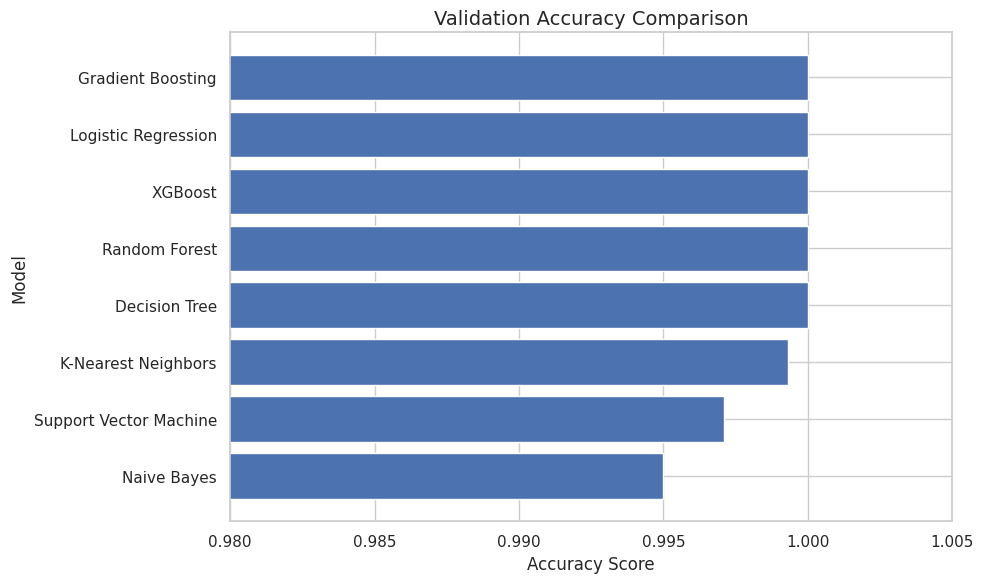

In [25]:
plt.figure(figsize=(10, 6))

performance_df_sorted = performance_df.sort_values(by='Accuracy', ascending=True)

plt.barh(performance_df_sorted.index, performance_df_sorted['Accuracy'])

plt.xlim(0.98, 1.005) 
plt.title('Validation Accuracy Comparison', fontsize=14)
plt.xlabel('Accuracy Score')
plt.ylabel('Model')

plt.tight_layout()
plt.show()

### Final Model Performance Analysis

### 1. Initial Leaderboard Results
Our initial evaluation showed that **Decision Tree**, **Logistic Regression**, **XGBoost**, **Random Forest**, and **Gradient Boosting** all achieved perfect scores (1.0) across all metrics. 
* **The Winner (Speed):** The Decision Tree was the most efficient, achieving perfection in only **0.0269 seconds**.
* **The "Safe" Models:** While Naive Bayes and SVM were slightly less accurate, they still performed above 99.5%, proving the features in this dataset are highly separable.

### 2. Hyperparameter Tuning Results (Cross-Validation)
The `GridSearchCV` confirmed that our perfect scores were not due to a lucky split. 
* **Decision Tree:** Remained perfect even when forced to a `max_depth` of 10.
* **XGBoost:** Achieved a Best CV Score of 1.0 using only 50 estimators and a shallow depth of 3. This indicates the model is highly robust and not overfitting.

**Conclusion:** We selected **XGBoost** as our final model for submission. While the Decision Tree is faster, XGBoost's boosting nature provides a more resilient boundary that typically generalizes better to unseen Kaggle test data.

### Feature importance Comparison

We also check which features contributed the most to the classification

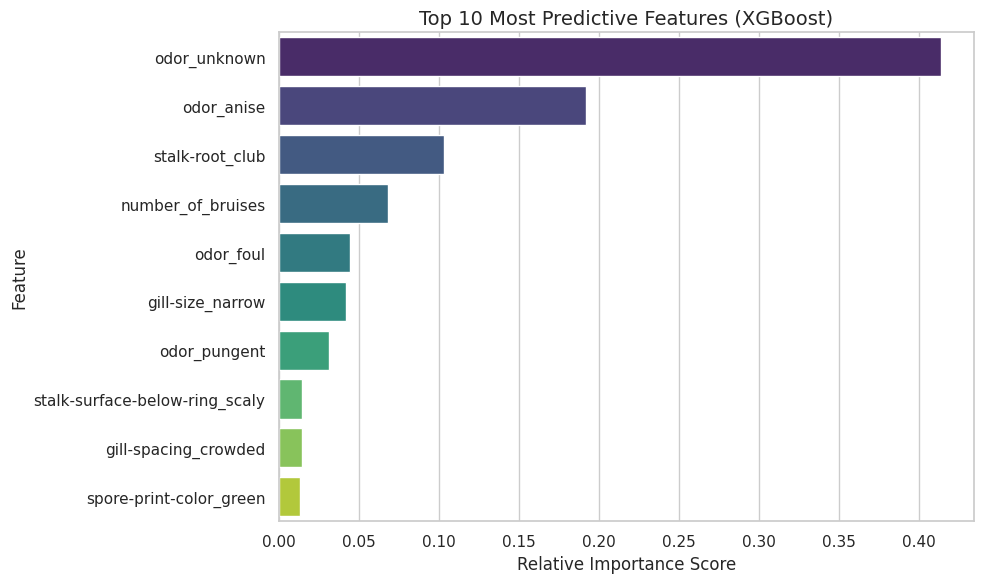

In [26]:
importances = best_model.feature_importances_
feature_names = X_train.columns

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')

plt.title('Top 10 Most Predictive Features (XGBoost)', fontsize=14)
plt.xlabel('Relative Importance Score')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

### Analysis

The feature importance plot shows that odor-related features are the most influential in predicting mushroom toxicity. In particular, `odor_unknown` and `odor_anise` have the highest importance, indicating that odor is a key distinguishing factor between edible and poisonous mushrooms.

Other important features include `stalk-root_club` and `number_of_bruises`, which also contribute significantly to the model’s predictions. Additionally, features such as cap color, gill size, and gill spacing provide supporting information and help refine the model’s decisions.

Overall, the model relies heavily on a few highly predictive features while using others for additional context, resulting in strong classification performance.

# Submission

In [27]:
submission = pd.read_csv('/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/sample_submission.csv')

final_preds_numeric = best_model.predict(X_test_encoded)
final_preds_labels = le.inverse_transform(final_preds_numeric)

submission['class'] = final_preds_labels

submission.to_csv('submission.csv', index=False)

submission.head()

,ID,class
0,1,e
1,2,e
2,3,e
3,4,e
4,5,e


In [28]:
print("Distribution:", pd.Series(final_preds_labels).value_counts())

Distribution: p    620
e    504
Name: count, dtype: int64
